In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120 

df = pd.read_csv('/Users/binhminh/Project-II/models/ocr/output/results_paddle_ocr.csv')

df_failed = df[df['ca_full'] == False].copy()
total_failed = len(df_failed)

print(f"Tổng số ảnh bị đọc sai toàn biển: {total_failed} / {len(df)} ảnh")

Tổng số ảnh bị đọc sai toàn biển: 37 / 350 ảnh


/var/folders/5b/lg2597jn17z4b_yr082m88tm0000gn/T/ipykernel_85689/2304329546.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categories, y=counts, palette='pastel')


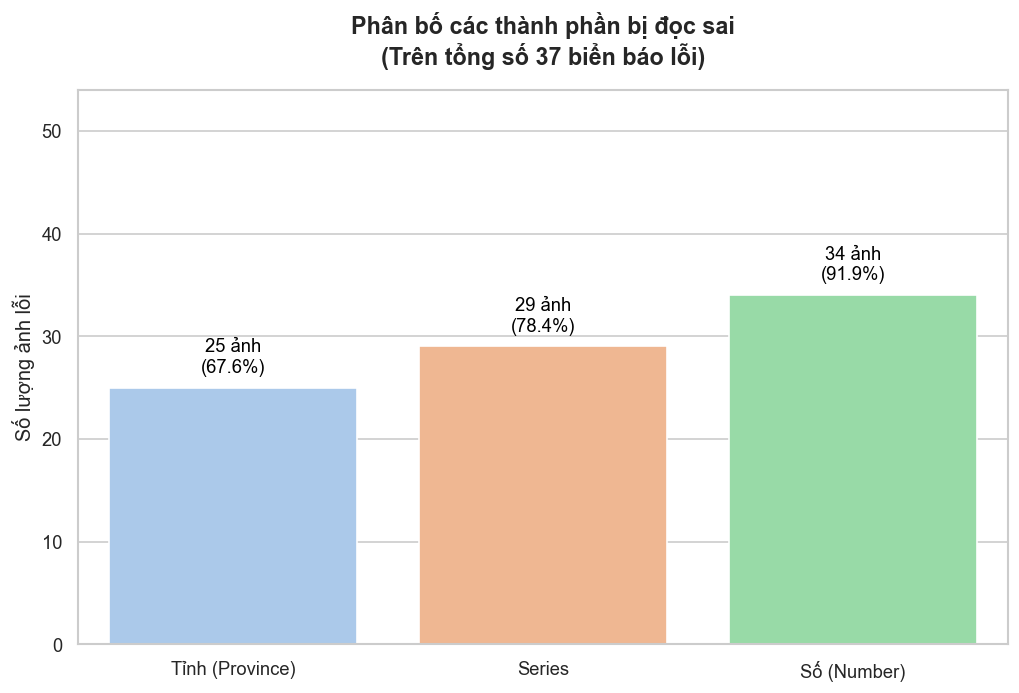

In [5]:
# Tính toán số lượng lỗi cho từng phần
err_prov = len(df_failed[df_failed['ca_province'] == False])
err_ser = len(df_failed[df_failed['ca_series'] == False])
err_num = len(df_failed[df_failed['ca_number'] == False])

categories = ['Tỉnh (Province)', 'Series', 'Số (Number)']
counts = [err_prov, err_ser, err_num]
percentages = [c / total_failed * 100 for c in counts]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=categories, y=counts, palette='pastel')

plt.title(f'Phân bố các thành phần bị đọc sai\n(Trên tổng số {total_failed} biển báo lỗi)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Số lượng ảnh lỗi', fontsize=12)

# Thêm text % lên đầu mỗi cột
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1.5,
            f'{counts[i]} ảnh\n({percentages[i]:.1f}%)',
            ha="center", fontsize=11, color='black')

plt.ylim(0, max(counts) + 20)
plt.show()

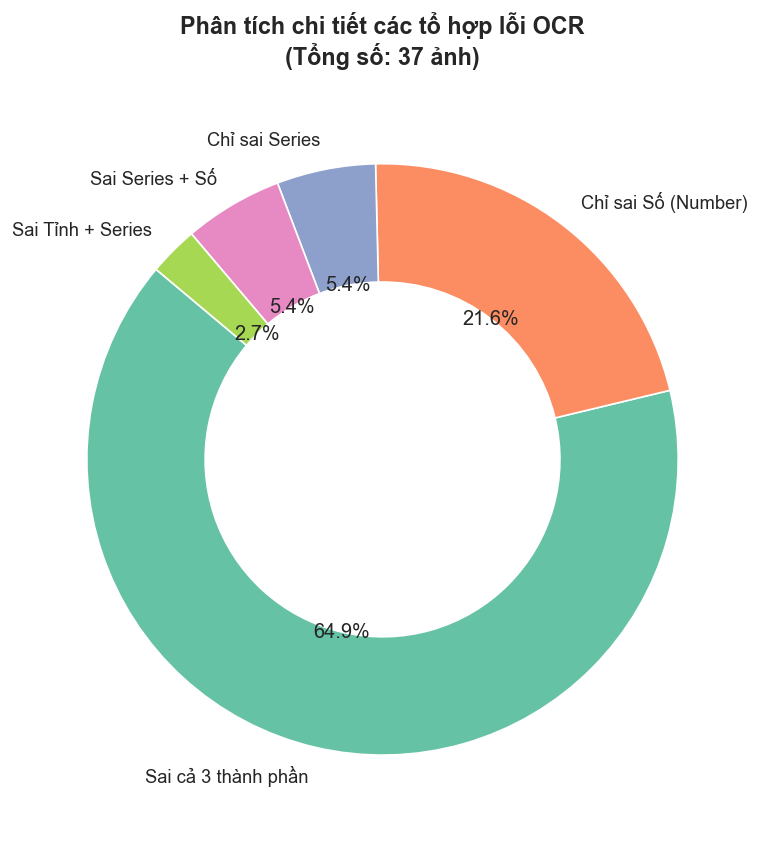

BẢNG THỐNG KÊ CHI TIẾT TỔ HỢP LỖI:


,Số lượng
error_type,
Sai cả 3 thành phần,24
Chỉ sai Số (Number),8
Chỉ sai Series,2
Sai Series + Số,2
Sai Tỉnh + Series,1


In [6]:
# Hàm phân loại tổ hợp lỗi
def get_error_combination(row):
    p = not row['ca_province']
    s = not row['ca_series']
    n = not row['ca_number']
    
    if p and not s and not n: return 'Chỉ sai Tỉnh'
    if not p and s and not n: return 'Chỉ sai Series'
    if not p and not s and n: return 'Chỉ sai Số (Number)'
    if p and s and not n: return 'Sai Tỉnh + Series'
    if p and not s and n: return 'Sai Tỉnh + Số'
    if not p and s and n: return 'Sai Series + Số'
    if p and s and n: return 'Sai cả 3 thành phần'
    return 'Lỗi định dạng khác'

# Áp dụng hàm phân loại
df_failed['error_type'] = df_failed.apply(get_error_combination, axis=1)
error_counts = df_failed['error_type'].value_counts()

# Vẽ biểu đồ Donut
plt.figure(figsize=(10, 8))
colors = sns.color_palette("Set2")

plt.pie(error_counts.values, labels=error_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))

plt.title(f'Phân tích chi tiết các tổ hợp lỗi OCR\n(Tổng số: {total_failed} ảnh)', fontsize=14, fontweight='bold', pad=15)
plt.show()

# In chi tiết dạng bảng
print("BẢNG THỐNG KÊ CHI TIẾT TỔ HỢP LỖI:")
display(error_counts.to_frame(name='Số lượng'))